## Étape 1 — Préparation des données


### 1.1 Imports et configuration


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

### 1.2 Chargement des données


In [5]:
german_credit = fetch_ucirepo(id=144)
X_raw = german_credit.data.features.copy()
y_raw = german_credit.data.targets.copy()

print(f'Shape features : {X_raw.shape}')
print(f'Distribution cible :\n{y_raw["class"].value_counts()}')
print(f'Missing values : {X_raw.isnull().sum().sum()}')
X_raw.head()

Shape features : (1000, 20)
Distribution cible :
class
1    700
2    300
Name: count, dtype: int64
Missing values : 0


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


### 1.3 Définition de l'attribut sensible (Âge) & Encodage des variables


In [6]:
df = X_raw.copy()
df['class'] = y_raw['class'].values

AGE_THRESHOLD = 25
df['age_group'] = (df['Attribute13'] >= AGE_THRESHOLD).astype(int)  # 1=senior, 0=jeune

feature_cols = [c for c in df.columns if c not in ['class', 'age_group']]
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include='number').columns.tolist()

df_encoded = df.copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

df_encoded['target'] = (df_encoded['class'] == 2).astype(int)
print(df_encoded['target'].value_counts())

target
0    700
1    300
Name: count, dtype: int64


### 1.4 Split Train / Test stratifié (80/20) & Normalisation


In [7]:
X = df_encoded[feature_cols].values
y = df_encoded['target'].values
sensitive = df_encoded['age_group'].values

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

num_indices = [feature_cols.index(c) for c in num_cols]
scaler = StandardScaler()
X_train_scaled = X_train.copy().astype(float)
X_test_scaled  = X_test.copy().astype(float)
X_train_scaled[:, num_indices] = scaler.fit_transform(X_train[:, num_indices])
X_test_scaled[:, num_indices]  = scaler.transform(X_test[:, num_indices])

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Train : 800 | Test : 200


### 1.5 Visualisation exploratoire (EDA)


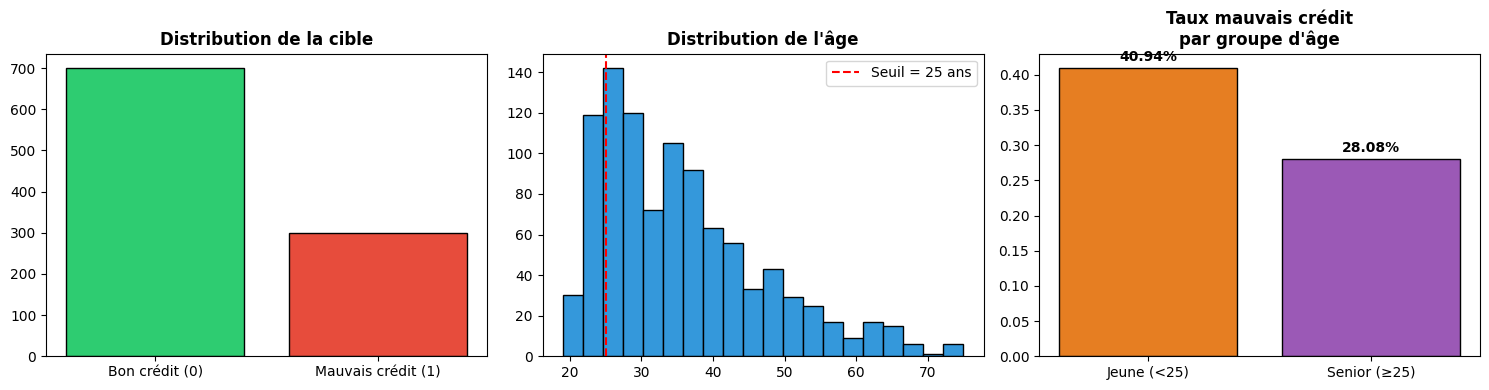

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Bon crédit (0)', 'Mauvais crédit (1)'],
            df_encoded['target'].value_counts().sort_index(),
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution de la cible', fontweight='bold')

axes[1].hist(df['Attribute13'], bins=20, color='#3498db', edgecolor='black')
axes[1].axvline(AGE_THRESHOLD, color='red', linestyle='--', label=f'Seuil = {AGE_THRESHOLD} ans')
axes[1].set_title("Distribution de l'âge", fontweight='bold')
axes[1].legend()

rate_by_age = df_encoded.groupby('age_group')['target'].mean()
axes[2].bar(['Jeune (<25)', 'Senior (≥25)'], rate_by_age.values,
            color=['#e67e22', '#9b59b6'], edgecolor='black')
axes[2].set_title("Taux mauvais crédit\npar groupe d'âge", fontweight='bold')
for i, v in enumerate(rate_by_age.values):
    axes[2].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Étape 2 — Modèle Baseline

### 2.1 Cost Matrix & Entraînement des modèles (Logistic Regression & Random Forest)


In [9]:
CLASS_WEIGHT = {0: 1, 1: 5}

def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

lr = LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=SEED)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print('Modèles entraînés ✓')

Modèles entraînés ✓


### 2.2 Évaluation sur le jeu de test


In [10]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Modèle'     : name,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'F1 (macro)' : f1_score(y_te, y_pred, average='macro'),
        'F1 (bad)'   : f1_score(y_te, y_pred, pos_label=1),
        'AUC-ROC'    : roc_auc_score(y_te, y_prob),
        'Coût total' : cost_matrix_score(y_te, y_pred),
    }

results_df = pd.DataFrame([
    evaluate_model('Logistic Regression', lr, X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf, X_test_scaled, y_test),
]).set_index('Modèle')

print(results_df.round(4).to_string())

                     Accuracy  F1 (macro)  F1 (bad)  AUC-ROC  Coût total
Modèle                                                                  
Logistic Regression     0.605      0.6033    0.5775   0.7923         103
Random Forest           0.730      0.6992    0.6029   0.8035         130


### 2.3 Matrices de confusion


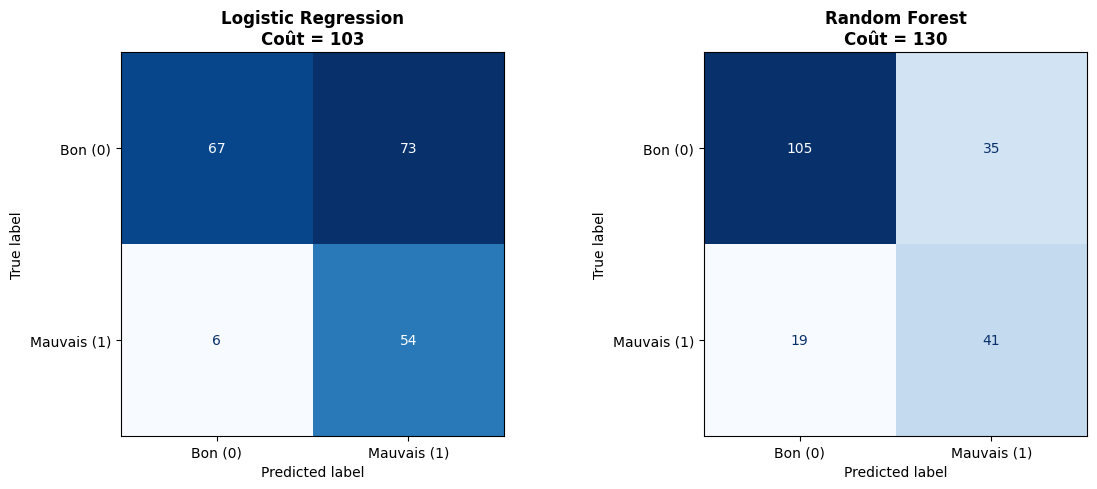

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Bon (0)', 'Mauvais (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nCoût = {cost_matrix_score(y_test, y_pred)}', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Validation croisée (5-fold stratifiée)


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
    print(f'{name}: AUC={auc.mean():.4f}±{auc.std():.4f} | F1={f1.mean():.4f}±{f1.std():.4f}')

Logistic Regression: AUC=0.7763±0.0554 | F1=0.6048±0.0257
Random Forest: AUC=0.7829±0.0411 | F1=0.6960±0.0329


### 2.5 Métriques de fairness préliminaires (avant mitigation)


In [13]:
def fairness_metrics(y_true, y_pred, sensitive, model_name=''):
    mask_young  = sensitive == 0
    mask_senior = sensitive == 1
    pr_young  = (y_pred[mask_young]  == 0).mean()
    pr_senior = (y_pred[mask_senior] == 0).mean()
    DI  = pr_young / pr_senior
    EOD = y_pred[mask_young & (y_true==1)].mean() - y_pred[mask_senior & (y_true==1)].mean()
    print(f'\n=== {model_name} ===')
    print(f'  DI  = {DI:.3f}  (idéal=1.0, seuil légal ≥ 0.8)')
    print(f'  EOD = {EOD:.3f}  (idéal=0.0)')

fairness_metrics(y_test, lr.predict(X_test_scaled), s_test, 'Logistic Regression')
fairness_metrics(y_test, rf.predict(X_test_scaled), s_test, 'Random Forest')


=== Logistic Regression ===
  DI  = 0.370  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.069  (idéal=0.0)

=== Random Forest ===
  DI  = 0.656  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.078  (idéal=0.0)


### 2.6 Sauvegarde du checkpoint


In [14]:
import pickle
checkpoint = {
    'X_train': X_train_scaled, 'X_test': X_test_scaled,
    'y_train': y_train, 'y_test': y_test,
    's_train': s_train, 's_test': s_test,
    'feature_cols': feature_cols, 'scaler': scaler, 'le_dict': le_dict,
    'baseline_lr': lr, 'baseline_rf': rf, 'SEED': SEED,
}
with open('checkpoint_etapes1_2.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)
print('Checkpoint sauvegardé ✓')

Checkpoint sauvegardé ✓


## Étape 3 — Équité Algorithmique : Méthodes de Mitigation

### 3.1 Chargement du checkpoint & Extraction du genre


In [17]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix)
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds, DemographicParity
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Chargement checkpoint
with open('checkpoint_etapes1_2.pkl', 'rb') as f:
    ck = pickle.load(f)

X_train = ck['X_train']
X_test  = ck['X_test']
y_train = ck['y_train']
y_test  = ck['y_test']
s_train = ck['s_train']  # âge
s_test  = ck['s_test']
feature_cols = ck['feature_cols']
lr_base = ck['baseline_lr']
rf_base = ck['baseline_rf']
SEED = ck['SEED']

print('Checkpoint chargé ✓')

Checkpoint chargé ✓


### 3.2 Extraction du genre (Attribute9) & Reconstruction du split


In [18]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

german_credit = fetch_ucirepo(id=144)
X_raw = german_credit.data.features.copy()
y_raw = german_credit.data.targets.copy()

# Extraction genre depuis Attribute9
# A91/A93/A94 = male, A92/A95 = female
gender_map = {
    'A91': 0,  # male
    'A92': 1,  # female
    'A93': 0,  # male
    'A94': 0,  # male
    'A95': 1,  # female
}
gender = X_raw['Attribute9'].map(gender_map).values  # 0=male, 1=female

# Âge (déjà calculé)
age_group = (X_raw['Attribute13'] >= 25).astype(int).values  # 0=jeune, 1=senior

# Target
target = (y_raw['class'] == 2).astype(int).values

# On refait le même split avec random_state=42 pour être cohérent
from sklearn.model_selection import train_test_split
idx = np.arange(len(target))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=target)

gender_train, gender_test = gender[idx_train], gender[idx_test]
age_train,    age_test    = age_group[idx_train], age_group[idx_test]

print(f'Distribution genre — Train: {pd.Series(gender_train).value_counts().to_dict()}')
print(f'Distribution genre — Test : {pd.Series(gender_test).value_counts().to_dict()}')
print(f'  0 = male | 1 = female')

Distribution genre — Train: {0: 551, 1: 249}
Distribution genre — Test : {0: 139, 1: 61}
  0 = male | 1 = female


### 3.3 Fonction d'évaluation complète (Performance + Fairness)


In [19]:
def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

def evaluate_full(name, y_true, y_pred, y_prob, sensitive_age, sensitive_gender):
    """Métriques performance + fairness âge + fairness genre."""
    
    # Performance
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    auc  = roc_auc_score(y_true, y_prob)
    cost = cost_matrix_score(y_true, y_pred)
    
    # Fairness — Âge
    di_age  = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_age)
    eod_age = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_age)
    
    # Fairness — Genre
    di_gender  = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_gender)
    eod_gender = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_gender)
    
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 macro  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  Coût      : {cost}')
    print(f'  --- Fairness Âge ---')
    print(f'  DP diff   : {di_age:.4f}   (idéal=0, |val|<0.1 acceptable)')
    print(f'  EOD       : {eod_age:.4f}   (idéal=0)')
    print(f'  --- Fairness Genre ---')
    print(f'  DP diff   : {di_gender:.4f}   (idéal=0)')
    print(f'  EOD       : {di_gender:.4f}   (idéal=0)')
    
    return {
        'Modèle': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'Coût': cost,
        'DP_age': di_age, 'EOD_age': eod_age,
        'DP_gender': di_gender, 'EOD_gender': eod_gender
    }

print('Fonction définie ✓')

Fonction définie ✓


### 3.4 Scores de référence baseline (avant mitigation)


In [20]:
# Scores baseline (avant mitigation) — référence
print('=== BASELINE (avant mitigation) ===')
baseline_results = []

for name, model in [('LR baseline', lr_base), ('RF baseline', rf_base)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    r = evaluate_full(name, y_test, y_pred, y_prob, age_test, gender_test)
    baseline_results.append(r)

=== BASELINE (avant mitigation) ===

  LR baseline
  Accuracy  : 0.6050
  F1 macro  : 0.6033
  AUC-ROC   : 0.7923
  Coût      : 103
  --- Fairness Âge ---
  DP diff   : 0.2623   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.2667   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1242   (idéal=0)
  EOD       : 0.1242   (idéal=0)

  RF baseline
  Accuracy  : 0.7300
  F1 macro  : 0.6992
  AUC-ROC   : 0.8035
  Coût      : 130
  --- Fairness Âge ---
  DP diff   : 0.2287   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.1750   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1373   (idéal=0)
  EOD       : 0.1373   (idéal=0)


### 3.5 Méthode 1 : Reweighing (pré-traitement)

Calcul des poids pour équilibrer la représentation des groupes (âge, genre, combiné) dans l'entraînement.


In [21]:
# Reweighing : on calcule des poids pour équilibrer la représentation
# des groupes (âge x genre x target) dans l'entraînement

def compute_reweighing_weights(y, sensitive):
    """Calcule les poids de reweighing pour un attribut sensible."""
    df_w = pd.DataFrame({'y': y, 's': sensitive})
    n = len(df_w)
    
    # P(s) et P(y)
    p_s = df_w['s'].value_counts(normalize=True)
    p_y = df_w['y'].value_counts(normalize=True)
    
    weights = np.ones(n)
    for i, row in df_w.iterrows():
        p_sy = len(df_w[(df_w['s']==row['s']) & (df_w['y']==row['y'])]) / n
        w = (p_s[row['s']] * p_y[row['y']]) / p_sy
        weights[i] = w
    return weights

# Reweighing sur l'âge
w_age = compute_reweighing_weights(y_train, age_train)

# Reweighing sur le genre
w_gender = compute_reweighing_weights(y_train, gender_train)

# Reweighing combiné (âge + genre) — on multiplie et normalise
w_combined = w_age * w_gender
w_combined = w_combined / w_combined.mean()  # normalisation

print(f'Poids reweighing âge    — min:{w_age.min():.3f} max:{w_age.max():.3f}')
print(f'Poids reweighing genre  — min:{w_gender.min():.3f} max:{w_gender.max():.3f}')
print(f'Poids reweighing combiné— min:{w_combined.min():.3f} max:{w_combined.max():.3f}')

Poids reweighing âge    — min:0.786 max:1.132
Poids reweighing genre  — min:0.839 max:1.095
Poids reweighing combiné— min:0.659 max:1.232


### 3.6 Entraînement des modèles avec Reweighing


In [22]:
CLASS_WEIGHT = {0: 1, 1: 5}

# LR avec reweighing âge
lr_rw_age = LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=SEED)
lr_rw_age.fit(X_train, y_train, sample_weight=w_age)

# RF avec reweighing âge
rf_rw_age = RandomForestClassifier(n_estimators=200, max_depth=8,
                                    class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_age.fit(X_train, y_train, sample_weight=w_age)

# RF avec reweighing genre
rf_rw_gender = RandomForestClassifier(n_estimators=200, max_depth=8,
                                       class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_gender.fit(X_train, y_train, sample_weight=w_gender)

# RF avec reweighing combiné
rf_rw_combined = RandomForestClassifier(n_estimators=200, max_depth=8,
                                         class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_combined.fit(X_train, y_train, sample_weight=w_combined)

print('Modèles reweighing entraînés ✓')

Modèles reweighing entraînés ✓


### 3.7 Méthode 2 : Fairlearn — ExponentiatedGradient (en cours d'apprentissage)

- `EqualizedOdds` appliqué sur l'âge
- `DemographicParity` appliqué sur le genre


In [24]:
# ExponentiatedGradient avec contrainte EqualizedOdds sur l'âge
eg_age = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=8,
                                      class_weight=CLASS_WEIGHT, random_state=SEED),
    constraints=EqualizedOdds(),
    max_iter=50
)
eg_age.fit(X_train, y_train, sensitive_features=age_train)

# ExponentiatedGradient avec contrainte DemographicParity sur le genre
eg_gender = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=8,
                                      class_weight=CLASS_WEIGHT, random_state=SEED),
    constraints=DemographicParity(),
    max_iter=50
)
eg_gender.fit(X_train, y_train, sensitive_features=gender_train)

print('Modèles Fairlearn entraînés ✓')

Modèles Fairlearn entraînés ✓


### 3.8 Évaluation comparative — tous les modèles


In [25]:
print('\n=== ÉVALUATION COMPLÈTE ===')
all_results = baseline_results.copy()

models_to_eval = [
    ('LR + Reweighing (âge)',      lr_rw_age),
    ('RF + Reweighing (âge)',      rf_rw_age),
    ('RF + Reweighing (genre)',    rf_rw_gender),
    ('RF + Reweighing (combiné)',  rf_rw_combined),
    ('RF + Fairlearn EO (âge)',    eg_age),
    ('RF + Fairlearn DP (genre)',  eg_gender),
]

for name, model in models_to_eval:
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_prob = model._pmf_predict(X_test)[:, 1]
    r = evaluate_full(name, y_test, y_pred, y_prob, age_test, gender_test)
    all_results.append(r)


=== ÉVALUATION COMPLÈTE ===

  LR + Reweighing (âge)
  Accuracy  : 0.5900
  F1 macro  : 0.5890
  AUC-ROC   : 0.7888
  Coût      : 106
  --- Fairness Âge ---
  DP diff   : 0.2437   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.2417   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1026   (idéal=0)
  EOD       : 0.1026   (idéal=0)

  RF + Reweighing (âge)
  Accuracy  : 0.7400
  F1 macro  : 0.7103
  AUC-ROC   : 0.8005
  Coût      : 124
  --- Fairness Âge ---
  DP diff   : 0.1650   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.0667   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.0665   (idéal=0)
  EOD       : 0.0665   (idéal=0)

  RF + Reweighing (genre)
  Accuracy  : 0.7300
  F1 macro  : 0.6970
  AUC-ROC   : 0.8054
  Coût      : 134
  --- Fairness Âge ---
  DP diff   : 0.2093   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.1250   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.0809   (idéal=0)
  EOD       : 0.0809   (idéal=0)

  RF + Reweighing (combiné)
  Accuracy  : 0.

### 3.9 Tableau comparatif & Graphique des compromis Performance / Équité



=== TABLEAU COMPARATIF ===
                           Accuracy      F1     AUC  Coût  DP_age  EOD_age  DP_gender  EOD_gender
Modèle                                                                                           
LR baseline                   0.605  0.6033  0.7923   103  0.2623   0.2667     0.1242      0.1249
RF baseline                   0.730  0.6992  0.8035   130  0.2287   0.1750     0.1373      0.1293
LR + Reweighing (âge)         0.590  0.5890  0.7888   106  0.2437   0.2417     0.1026      0.0946
RF + Reweighing (âge)         0.740  0.7103  0.8005   124  0.1650   0.0667     0.0665      0.0750
RF + Reweighing (genre)       0.730  0.6970  0.8054   134  0.2093   0.1250     0.0809      0.1250
RF + Reweighing (combiné)     0.760  0.7326  0.8106   112  0.1650   0.0833     0.0665      0.0562
RF + Fairlearn EO (âge)       0.725  0.6947  0.7346   131  0.1588   0.0783     0.1773      0.1882
RF + Fairlearn DP (genre)     0.735  0.7037  0.7652   129  0.1394   0.0667     0.0501     

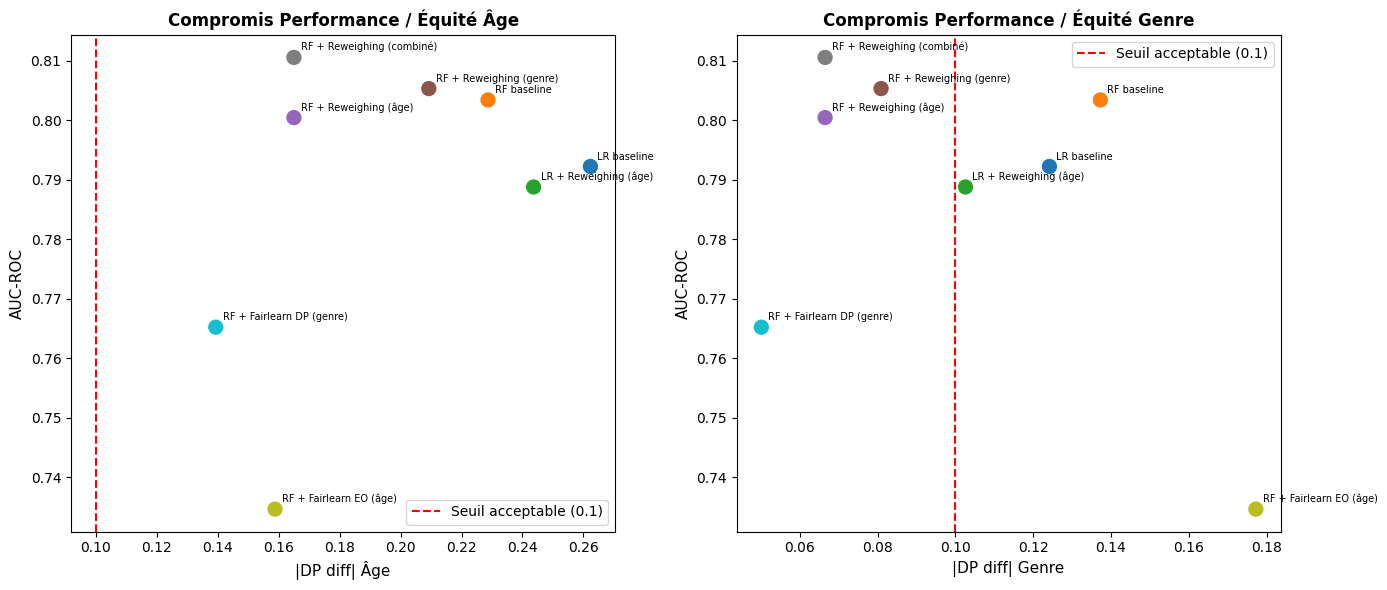

Figure sauvegardée : fairness_tradeoff.png


In [26]:
results_df = pd.DataFrame(all_results).set_index('Modèle')
print('\n=== TABLEAU COMPARATIF ===')
print(results_df.round(4).to_string())

# Graphique : AUC vs DP_age
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AUC vs Fairness âge
axes[0].scatter(results_df['DP_age'].abs(), results_df['AUC'],
                s=100, c=range(len(results_df)), cmap='tab10', zorder=5)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0].annotate(idx, (abs(row['DP_age']), row['AUC']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)
axes[0].axvline(0.1, color='red', linestyle='--', label='Seuil acceptable (0.1)')
axes[0].set_xlabel('|DP diff| Âge', fontsize=11)
axes[0].set_ylabel('AUC-ROC', fontsize=11)
axes[0].set_title('Compromis Performance / Équité Âge', fontweight='bold')
axes[0].legend()

# AUC vs Fairness genre
axes[1].scatter(results_df['DP_gender'].abs(), results_df['AUC'],
                s=100, c=range(len(results_df)), cmap='tab10', zorder=5)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[1].annotate(idx, (abs(row['DP_gender']), row['AUC']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)
axes[1].axvline(0.1, color='red', linestyle='--', label='Seuil acceptable (0.1)')
axes[1].set_xlabel('|DP diff| Genre', fontsize=11)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('Compromis Performance / Équité Genre', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fairness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : fairness_tradeoff.png')

### 3.10 Sauvegarde du checkpoint étape 3


In [27]:
with open('checkpoint_etape3.pkl', 'wb') as f:
    pickle.dump({
        'rf_rw_age': rf_rw_age,
        'rf_rw_gender': rf_rw_gender,
        'rf_rw_combined': rf_rw_combined,
        'eg_age': eg_age,
        'eg_gender': eg_gender,
        'age_test': age_test,
        'gender_test': gender_test,
        'results_df': results_df,
        'SEED': SEED,
    }, f)
print('Checkpoint étape 3 sauvegardé ✓')

Checkpoint étape 3 sauvegardé ✓
